# Graph Sparsity, Information Propagation & Node Classification in GNNs
*Graph Representation Learning*

---

**Research question.** How does graph sparsity affect information propagation and node-classification performance in Graph Neural Networks?

**Abstract.** Sparsity sits at the centre of a fundamental trade-off in message passing: too few edges starve a node of signal (*under-reaching*), while too many drive representations toward a degree-dependent fixed point (*over-smoothing*). We treat sparsity as a controllable variable using Stochastic Block Model graphs of fixed community structure and variable average degree, and study its effect on (i) classification accuracy, (ii) over-smoothing via Dirichlet energy and Mean Average Distance, and (iii) Jacobian-based influence with distance. We then give a spectral explanation — linking both failure modes to the propagation operator's spectrum and the Laplacian spectral gap $\lambda_2$ — show that *which* edges are added matters as much as how many, and test robustness under heterophily. Findings are validated on the Cora citation network.

**Hypotheses.** H1 under-reaching at low degree · H2 over-smoothing at high density · H3 an accuracy sweet spot · H4 architecture-dependent robustness · H5 depth–sparsity interaction.

**Course concepts used.** SBM random graphs, transductive node classification, GCN/GAT/GIN/GraphSAGE, sum/mean aggregation and 1-WL, Dirichlet energy and Laplacian smoothing, spectral gap, Jacobian influence, over-squashing, DropEdge and graph rewiring (Lectures 3, 4, 6, 7, 8).

## Requirements & how to run
**Dependencies:** `torch`, `torch_geometric`, `networkx`, `numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`. If needed:

```bash
pip install torch torch_geometric networkx numpy pandas scipy matplotlib seaborn
```

**Run order:** execute the cells top to bottom. Sections 0–3 define everything the experiments rely on; Sections 4–8 are the core study; Sections 9–13 are the advanced extensions. All figures and CSVs are written to `./figures/`.

**Runtime tips:** the study runs on CPU. For a fast first pass, reduce the `SEEDS`/`*_SEEDS` lists to `[0]`; the heaviest cells are Experiment 1, Experiment 4 and Tier 3.

## Contents
**Part I — Setup**
0. Setup & reproducibility
1. Controllable-sparsity graphs (SBM)
2. Model architectures
3. Propagation metrics & training

**Part II — Core study**
4. Sparsity vs. accuracy
5. Over-smoothing vs. depth
6. Influence vs. distance
7. Depth × density interaction
8. Cora sparsification

**Part III — Advanced extensions**
9. Spectral & rewiring utilities
10. Tier 1a — the over-smoothing law
11. Tier 1b — spectral gap vs. edge count
12. Tier 2 — structure-aware rewiring
13. Tier 3 — heterophily robustness

14. Discussion, figures index & mapping to the report

---
# Part I — Experimental setup

## 0 · Setup, configuration & reproducibility
Imports, device selection, global seeding, and the `figures/` output directory. Seeding every library (`random`, `numpy`, `torch`) makes the reported numbers reproducible — a requirement for the experimental-setup section of the report.

In [1]:
import os, math, random
from collections import defaultdict
from pathlib import Path
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv
from torch_geometric.utils import to_networkx
from torch_geometric.datasets import Planetoid
try:
    from torch_geometric.utils import dropout_edge
except Exception:
    from torch_geometric.utils import dropout_adj
    def dropout_edge(edge_index, p=0.5, force_undirected=False):
        ei, _ = dropout_adj(edge_index, p=p, force_undirected=force_undirected)
        return ei, None

sns.set_theme(style="whitegrid", context="talk")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def set_seed(seed=0):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(0)
print("device:", DEVICE, "| figures ->", FIG_DIR.resolve())

device: cuda | figures -> /home/yash.lucas/GNN/figures


## 1 · Synthetic graphs with controllable sparsity
Graphs are drawn from a **Stochastic Block Model** (Lecture 7). The assortativity ratio `p_inter / p_intra` is held fixed while the **average degree** is varied, so *sparsity* is an isolated independent variable rather than a confound. Node features carry only a weak, noisy class signal, forcing the classifier to rely on neighbourhood aggregation. Transductive train/val/test masks follow Lecture 3.

In [2]:
def sbm_probs_from_avg_degree(n_per_block, n_blocks, avg_degree, ratio=0.1):
    denom = (n_per_block - 1) + ratio * n_per_block * (n_blocks - 1)
    p_intra = avg_degree / denom
    return float(np.clip(p_intra, 0, 1)), float(np.clip(ratio * p_intra, 0, 1))

def make_sbm_data(avg_degree, n_per_block=120, n_blocks=4, n_features=24,
                  signal=0.7, ratio=0.1, seed=0):
    set_seed(seed)
    sizes = [n_per_block] * n_blocks
    p_in, p_out = sbm_probs_from_avg_degree(n_per_block, n_blocks, avg_degree, ratio)
    P = np.full((n_blocks, n_blocks), p_out); np.fill_diagonal(P, p_in)
    G = nx.stochastic_block_model(sizes, P, seed=seed)
    y = np.concatenate([[b] * s for b, s in enumerate(sizes)]); N = len(y)
    class_means = np.random.randn(n_blocks, n_features)
    X = class_means[y] * signal + np.random.randn(N, n_features)
    edges = np.array(G.edges()).T
    if edges.size == 0: edges = np.empty((2, 0), dtype=int)
    edge_index = torch.tensor(np.concatenate([edges, edges[::-1]], axis=1), dtype=torch.long)
    data = Data(x=torch.tensor(X, dtype=torch.float), edge_index=edge_index,
                y=torch.tensor(y, dtype=torch.long))
    data.num_classes = n_blocks
    data.realized_avg_degree = 2 * edges.shape[1] / N if edges.size else 0.0
    return data

def add_random_splits(data, train_per_class=20, seed=0):
    set_seed(seed); N = data.num_nodes
    train = torch.zeros(N, dtype=torch.bool)
    for c in range(int(data.y.max()) + 1):
        idx = (data.y == c).nonzero(as_tuple=True)[0]
        idx = idx[torch.randperm(len(idx))]; train[idx[:train_per_class]] = True
    rest = (~train).nonzero(as_tuple=True)[0]; rest = rest[torch.randperm(len(rest))]
    half = len(rest) // 2
    val = torch.zeros(N, dtype=torch.bool);  val[rest[:half]] = True
    test = torch.zeros(N, dtype=torch.bool); test[rest[half:]] = True
    data.train_mask, data.val_mask, data.test_mask = train, val, test
    return data

d = add_random_splits(make_sbm_data(avg_degree=10, seed=0))
print("nodes:", d.num_nodes, "| edges:", d.edge_index.size(1)//2,
      "| realized avg degree:", round(d.realized_avg_degree, 2))

nodes: 480 | edges: 2382 | realized avg degree: 9.93


### 1.1 · Visualising the sparsity spectrum
Three SBM graphs from sparse to dense, with colour encoding the community label.

*Output:* `figures/01_sbm_sparsity_levels.png`

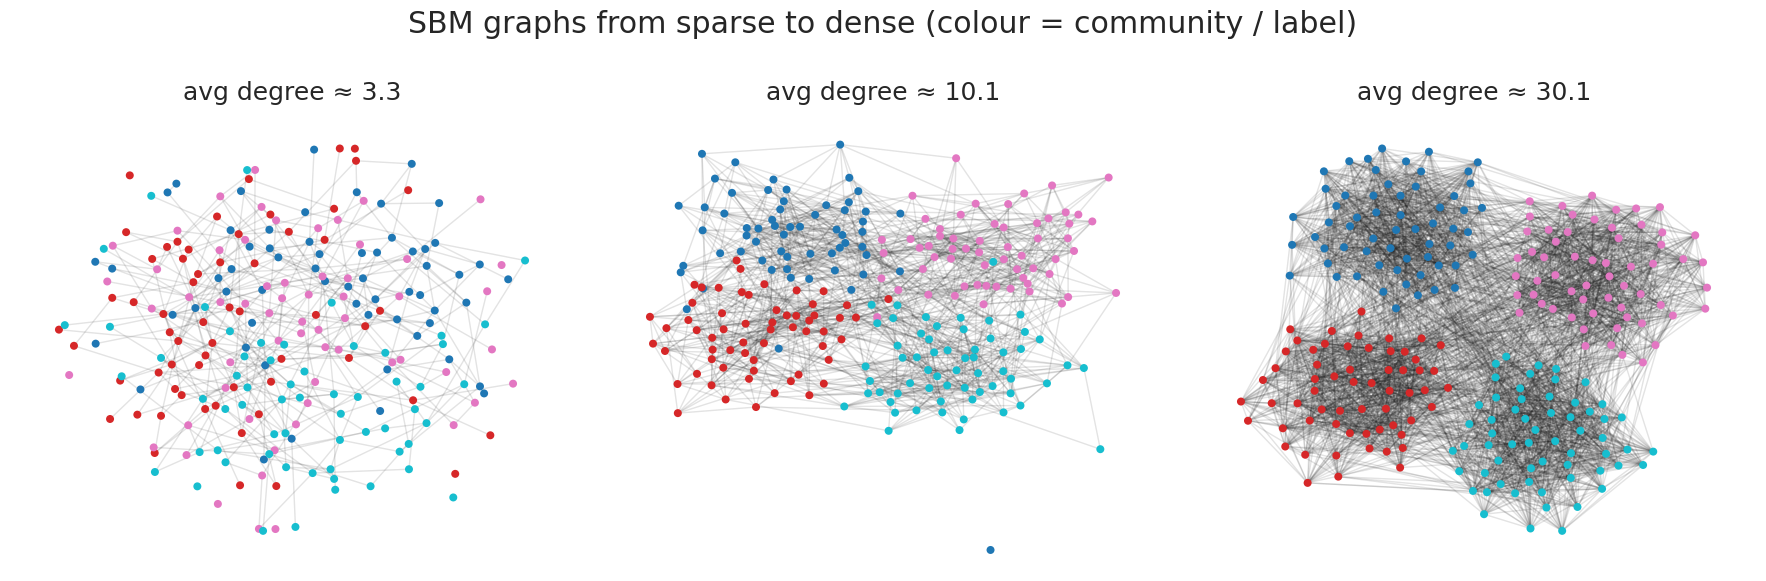

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, deg in zip(axes, [3, 10, 30]):
    g = make_sbm_data(avg_degree=deg, n_per_block=60, seed=1)
    G = to_networkx(g, to_undirected=True)
    pos = nx.spring_layout(G, seed=1, k=0.3)
    nx.draw_networkx_nodes(G, pos, node_size=18, node_color=g.y.numpy(), cmap="tab10", ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.12, ax=ax)
    ax.set_title(f"avg degree ≈ {g.realized_avg_degree:.1f}"); ax.axis("off")
fig.suptitle("SBM graphs from sparse to dense (colour = community / label)")
plt.tight_layout(); plt.savefig(FIG_DIR/"01_sbm_sparsity_levels.png", dpi=150, bbox_inches="tight"); plt.show()

## 2 · Model architectures
A single configurable message-passing backbone covering **GCN**, **GraphSAGE**, **GAT** and **GIN** (Lecture 4), plus a graph-agnostic **MLP** baseline that quantifies how much accuracy comes from propagation versus features alone. GIN's sum aggregator is the 1-WL-maximal case (Lecture 6); GCN's degree-normalised mean is the most smoothing-prone.

In [4]:
def make_conv(conv_type, in_dim, out_dim, heads=4):
    if conv_type == "gcn":  return GCNConv(in_dim, out_dim)
    if conv_type == "sage": return SAGEConv(in_dim, out_dim)
    if conv_type == "gat":
        assert out_dim % heads == 0
        return GATConv(in_dim, out_dim // heads, heads=heads, concat=True)
    if conv_type == "gin":
        mlp = nn.Sequential(nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, out_dim))
        return GINConv(mlp)
    raise ValueError(conv_type)

class GNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=2,
                 conv_type="gcn", dropout=0.5, heads=4):
        super().__init__()
        self.convs = nn.ModuleList()
        dims = [in_dim] + [hidden_dim] * num_layers
        for l in range(num_layers):
            self.convs.append(make_conv(conv_type, dims[l], dims[l+1], heads))
        self.classifier = nn.Linear(hidden_dim, out_dim); self.dropout = dropout
    def forward(self, x, edge_index):
        for l, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if l < len(self.convs) - 1:
                x = F.relu(x); x = F.dropout(x, p=self.dropout, training=self.training)
        emb = x
        return self.classifier(emb), emb

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(hidden_dim, out_dim))
    def forward(self, x, edge_index):
        h = self.net(x); return h, h
print("models defined")

models defined


## 3 · Information-propagation metrics
### 3.1 · Over-smoothing measures
**Dirichlet energy** (a symmetric-Laplacian smoothing measure, Lecture 7) and **Mean Average Distance**. Both decay toward zero as node representations become indistinguishable.

In [5]:
@torch.no_grad()
def dirichlet_energy(x, edge_index, num_nodes):
    deg = torch.zeros(num_nodes, device=x.device)
    deg.scatter_add_(0, edge_index[0], torch.ones(edge_index.size(1), device=x.device))
    xn = x * (1.0 / torch.sqrt(1.0 + deg)).unsqueeze(1)
    r, c = edge_index
    return ((xn[r]-xn[c]).pow(2).sum(1).sum() / (2.0*num_nodes)).item()

@torch.no_grad()
def mean_average_distance(x):
    xn = F.normalize(x, dim=1); dist = 1.0 - xn @ xn.t(); N = x.size(0)
    return ((dist.sum() - torch.diagonal(dist).sum()) / (N*(N-1))).item()

def influence_by_distance(model, data, num_targets=30, max_dist=6, seed=0):
    model.eval(); G = to_networkx(data, to_undirected=True)
    rng = np.random.default_rng(seed)
    targets = rng.choice(data.num_nodes, size=min(num_targets, data.num_nodes), replace=False)
    bucket = defaultdict(list)
    for t in targets:
        x = data.x.clone().detach().requires_grad_(True)
        _, emb = model(x, data.edge_index)
        grad = torch.autograd.grad(emb[t].sum(), x)[0]
        infl = grad.abs().sum(1); infl = infl / (infl.sum() + 1e-12)
        for node, dst in nx.single_source_shortest_path_length(G, t, cutoff=max_dist).items():
            bucket[dst].append(infl[node].item())
    return {k: float(np.mean(v)) for k, v in sorted(bucket.items())}
print("metrics defined")

metrics defined


### 3.2 · Jacobian influence
Influence of a source node on a target, $I(i,j)=\lVert\partial h_i/\partial x_j\rVert_1$, binned by shortest-path distance — a direct probe of the receptive field and of over-squashing (Lecture 7).

In [6]:
@torch.no_grad()
def dirichlet_energy(x, edge_index, num_nodes):
    deg = torch.zeros(num_nodes, device=x.device)
    deg.scatter_add_(0, edge_index[0], torch.ones(edge_index.size(1), device=x.device))
    xn = x * (1.0 / torch.sqrt(1.0 + deg)).unsqueeze(1)
    r, c = edge_index
    return ((xn[r]-xn[c]).pow(2).sum(1).sum() / (2.0*num_nodes)).item()

@torch.no_grad()
def mean_average_distance(x):
    xn = F.normalize(x, dim=1); dist = 1.0 - xn @ xn.t(); N = x.size(0)
    return ((dist.sum() - torch.diagonal(dist).sum()) / (N*(N-1))).item()

def influence_by_distance(model, data, num_targets=30, max_dist=6, seed=0):
    model.eval(); G = to_networkx(data, to_undirected=True)
    rng = np.random.default_rng(seed)
    targets = rng.choice(data.num_nodes, size=min(num_targets, data.num_nodes), replace=False)
    bucket = defaultdict(list)
    for t in targets:
        x = data.x.clone().detach().requires_grad_(True)
        _, emb = model(x, data.edge_index)
        grad = torch.autograd.grad(emb[t].sum(), x)[0]
        infl = grad.abs().sum(1); infl = infl / (infl.sum() + 1e-12)
        for node, dst in nx.single_source_shortest_path_length(G, t, cutoff=max_dist).items():
            bucket[dst].append(infl[node].item())
    return {k: float(np.mean(v)) for k, v in sorted(bucket.items())}
print("metrics defined")

metrics defined


### 3.3 · Training & evaluation
Standard transductive node-classification loop: Adam, weight decay, cross-entropy, with best-validation model selection. All hyper-parameters are explicit for the report.

In [7]:
def train_node_classifier(data, model, epochs=200, lr=0.01, wd=5e-4):
    data = data.to(DEVICE); model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    best_val, best_test = 0.0, 0.0
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        out, _ = model(data.x, data.edge_index)
        F.cross_entropy(out[data.train_mask], data.y[data.train_mask]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index)[0].argmax(1)
            val  = (pred[data.val_mask]  == data.y[data.val_mask]).float().mean().item()
            test = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()
        if val >= best_val: best_val, best_test = val, test
    return best_test
print("trainer ready")

trainer ready


---
# Part II — Core study: sparsity, propagation & accuracy
## 4 · Experiment 1 — Sparsity vs. classification accuracy
Sweeps the average degree across all architectures and the MLP baseline. Tests **H1** (under-reaching at low degree), **H3** (an accuracy sweet spot) and **H4** (architecture ordering).

*Output:* `figures/02_accuracy_vs_sparsity.png`, `figures/exp1_accuracy.csv`

degree   1 done
degree   2 done
degree   3 done
degree   5 done
degree   8 done
degree  12 done
degree  18 done
degree  26 done
degree  40 done


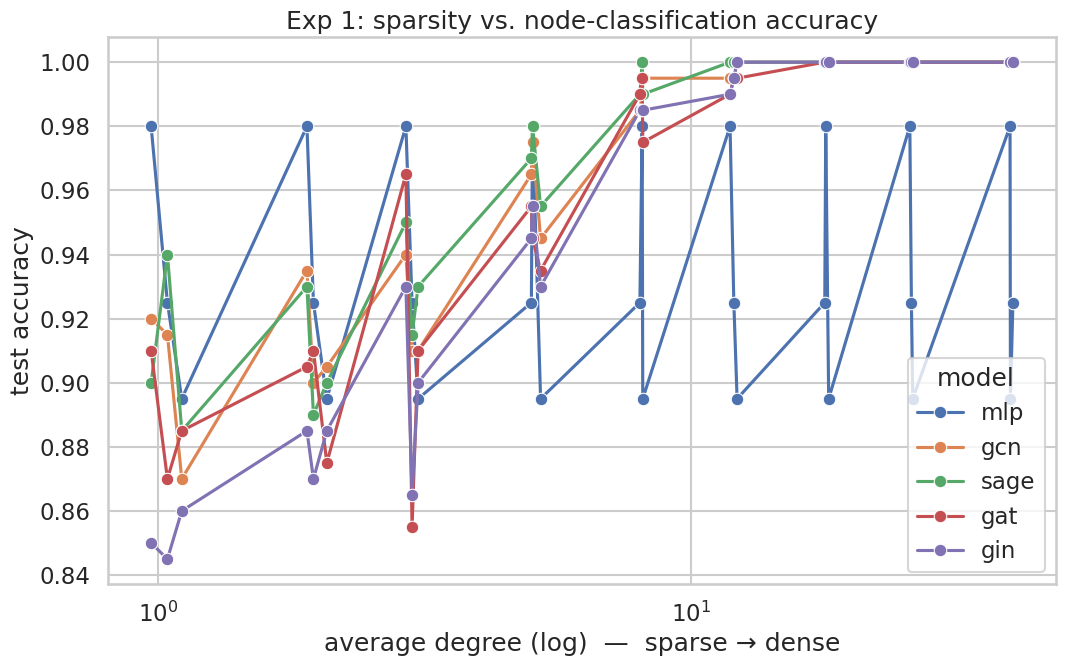

In [8]:
DEGREES = [1,2,3,5,8,12,18,26,40]; ARCHS = ["gcn","sage","gat","gin"]; SEEDS=[0,1,2]
HID, NLAYERS = 64, 2; rows = []
for deg in DEGREES:
    for seed in SEEDS:
        data = add_random_splits(make_sbm_data(avg_degree=deg, seed=seed), seed=seed)
        in_dim, out_dim = data.num_node_features, data.num_classes
        acc = train_node_classifier(data, MLP(in_dim, HID, out_dim))
        rows.append(dict(degree=data.realized_avg_degree, model="mlp", seed=seed, acc=acc))
        for arch in ARCHS:
            acc = train_node_classifier(data, GNN(in_dim, HID, out_dim, NLAYERS, arch))
            rows.append(dict(degree=data.realized_avg_degree, model=arch, seed=seed, acc=acc))
    print(f"degree {deg:>3} done")
df1 = pd.DataFrame(rows)
plt.figure(figsize=(11,7))
sns.lineplot(data=df1, x="degree", y="acc", hue="model", marker="o", errorbar="sd")
plt.xscale("log"); plt.xlabel("average degree (log)  —  sparse → dense"); plt.ylabel("test accuracy")
plt.title("Exp 1: sparsity vs. node-classification accuracy"); plt.tight_layout()
plt.savefig(FIG_DIR/"02_accuracy_vs_sparsity.png", dpi=150, bbox_inches="tight"); plt.show()
df1.to_csv(FIG_DIR/"exp1_accuracy.csv", index=False)

## 5 · Experiment 2 — Over-smoothing vs. depth
Dirichlet energy and MAD as network depth grows, at three sparsity levels. Tests **H2**: denser graphs over-smooth faster (Laplacian smoothing).

*Output:* `figures/03_oversmoothing_vs_depth.png`, `figures/exp2_oversmoothing.csv`

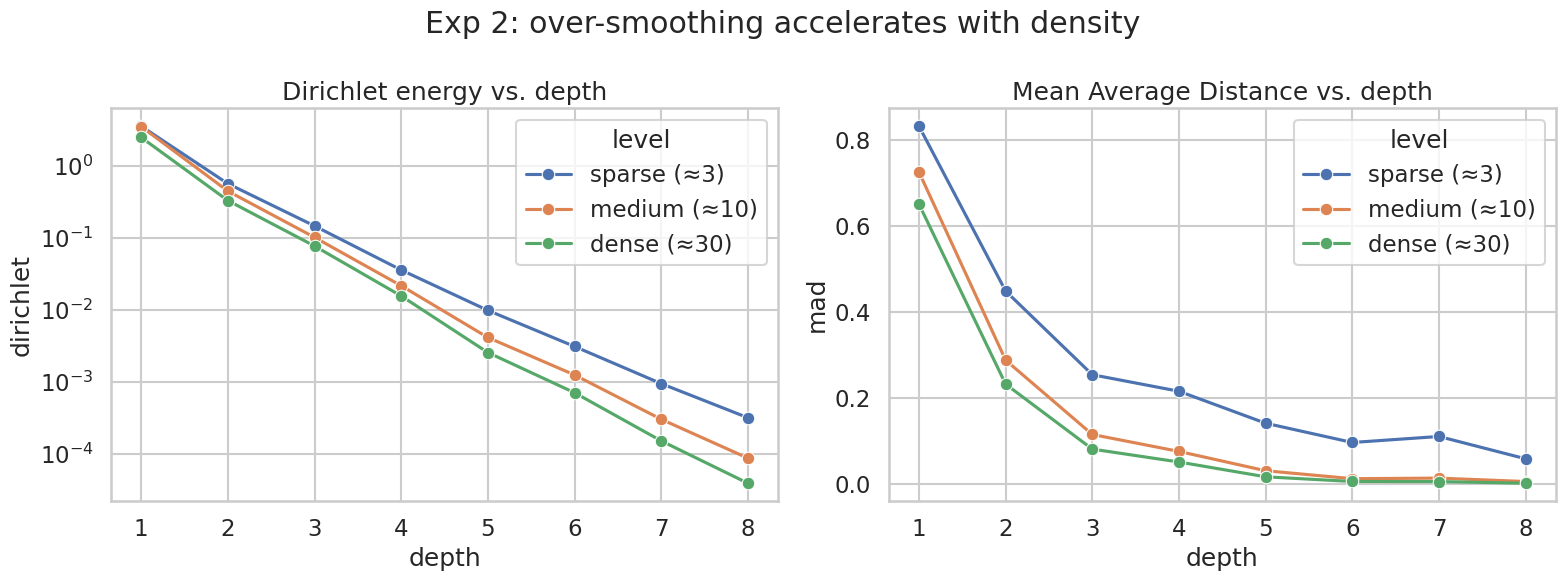

In [9]:
DEPTHS = list(range(1,9)); LEVELS = {"sparse (≈3)":3, "medium (≈10)":10, "dense (≈30)":30}
rows = []
for name, deg in LEVELS.items():
    data = add_random_splits(make_sbm_data(avg_degree=deg, seed=0), seed=0).to(DEVICE)
    for L in DEPTHS:
        set_seed(0)
        model = GNN(data.num_node_features, 64, data.num_classes, L, "gcn", dropout=0.0).to(DEVICE).eval()
        with torch.no_grad(): _, emb = model(data.x, data.edge_index)
        rows.append(dict(level=name, depth=L,
                         dirichlet=dirichlet_energy(emb, data.edge_index, data.num_nodes),
                         mad=mean_average_distance(emb)))
df2 = pd.DataFrame(rows)
fig, ax = plt.subplots(1,2, figsize=(16,6))
sns.lineplot(data=df2, x="depth", y="dirichlet", hue="level", marker="o", ax=ax[0])
ax[0].set_yscale("log"); ax[0].set_title("Dirichlet energy vs. depth")
sns.lineplot(data=df2, x="depth", y="mad", hue="level", marker="o", ax=ax[1])
ax[1].set_title("Mean Average Distance vs. depth")
fig.suptitle("Exp 2: over-smoothing accelerates with density"); plt.tight_layout()
plt.savefig(FIG_DIR/"03_oversmoothing_vs_depth.png", dpi=150, bbox_inches="tight"); plt.show()
df2.to_csv(FIG_DIR/"exp2_oversmoothing.csv", index=False)

## 6 · Experiment 3 — Influence vs. distance
Influence-decay profiles at three sparsity levels using an **untrained** GCN, which isolates the purely structural component of propagation. Steeper decay indicates under-reaching / over-squashing.

*Output:* `figures/04_influence_vs_distance.png`, `figures/exp3_influence.csv`

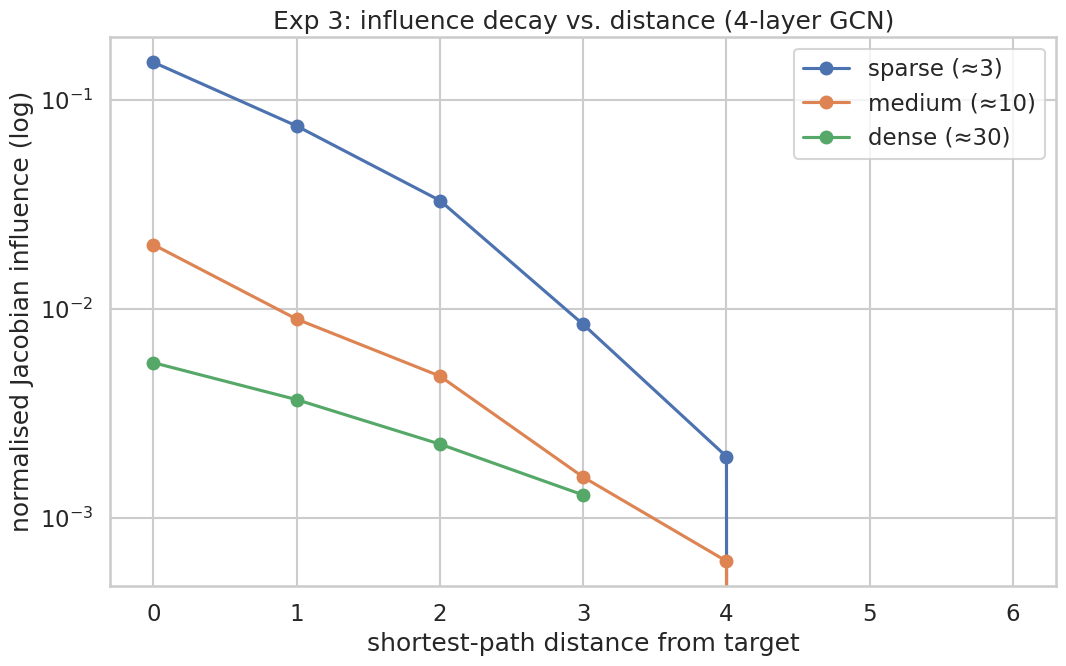

In [10]:
plt.figure(figsize=(11,7)); df3_rows = []
for name, deg in {"sparse (≈3)":3,"medium (≈10)":10,"dense (≈30)":30}.items():
    data = make_sbm_data(avg_degree=deg, seed=0); set_seed(0)
    model = GNN(data.num_node_features, 64, data.num_classes, 4, "gcn", dropout=0.0)
    prof = influence_by_distance(model, data, num_targets=40, max_dist=6, seed=0)
    plt.plot(list(prof.keys()), list(prof.values()), marker="o", label=name)
    for k,v in prof.items(): df3_rows.append(dict(level=name, distance=k, influence=v))
plt.yscale("log"); plt.xlabel("shortest-path distance from target")
plt.ylabel("normalised Jacobian influence (log)")
plt.title("Exp 3: influence decay vs. distance (4-layer GCN)"); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR/"04_influence_vs_distance.png", dpi=150, bbox_inches="tight"); plt.show()
pd.DataFrame(df3_rows).to_csv(FIG_DIR/"exp3_influence.csv", index=False)

## 7 · Experiment 4 — Depth × density interaction
Accuracy across the full (depth, average-degree) grid as a heatmap. Tests **H5**: the optimal depth shifts as the graph becomes denser.

*Output:* `figures/05_depth_density_heatmap.png`, `figures/exp4_heatmap.csv`

degree 2 column done
degree 4 column done
degree 8 column done
degree 16 column done
degree 30 column done


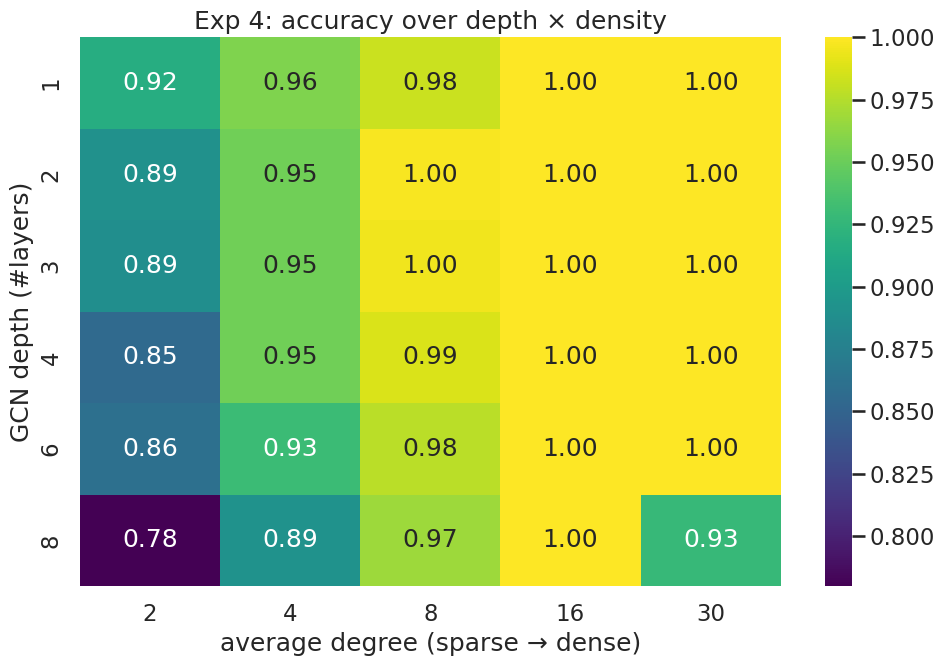

In [11]:
GRID_DEG=[2,4,8,16,30]; GRID_DEPTH=[1,2,3,4,6,8]; GRID_SEEDS=[0,1]
mat = np.zeros((len(GRID_DEPTH), len(GRID_DEG)))
for j, deg in enumerate(GRID_DEG):
    for i, L in enumerate(GRID_DEPTH):
        accs=[]
        for s in GRID_SEEDS:
            data = add_random_splits(make_sbm_data(avg_degree=deg, seed=s), seed=s)
            accs.append(train_node_classifier(data, GNN(data.num_node_features,64,data.num_classes,L,"gcn")))
        mat[i,j] = np.mean(accs)
    print(f"degree {deg} column done")
plt.figure(figsize=(10,7))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="viridis", xticklabels=GRID_DEG, yticklabels=GRID_DEPTH)
plt.xlabel("average degree (sparse → dense)"); plt.ylabel("GCN depth (#layers)")
plt.title("Exp 4: accuracy over depth × density"); plt.tight_layout()
plt.savefig(FIG_DIR/"05_depth_density_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
pd.DataFrame(mat, index=GRID_DEPTH, columns=GRID_DEG).to_csv(FIG_DIR/"exp4_heatmap.csv")

## 8 · Experiment 5 — Real graph (Cora) sparsification
A **DropEdge-style** intervention (Lecture 7): random edge removal on the Cora citation network, tracking both accuracy and Dirichlet energy. Provides external validity for the synthetic findings.

*Output:* `figures/06_cora_sparsification.png`, `figures/exp5_cora.csv`

drop 0.0 done
drop 0.2 done
drop 0.4 done
drop 0.6 done
drop 0.8 done
drop 0.9 done


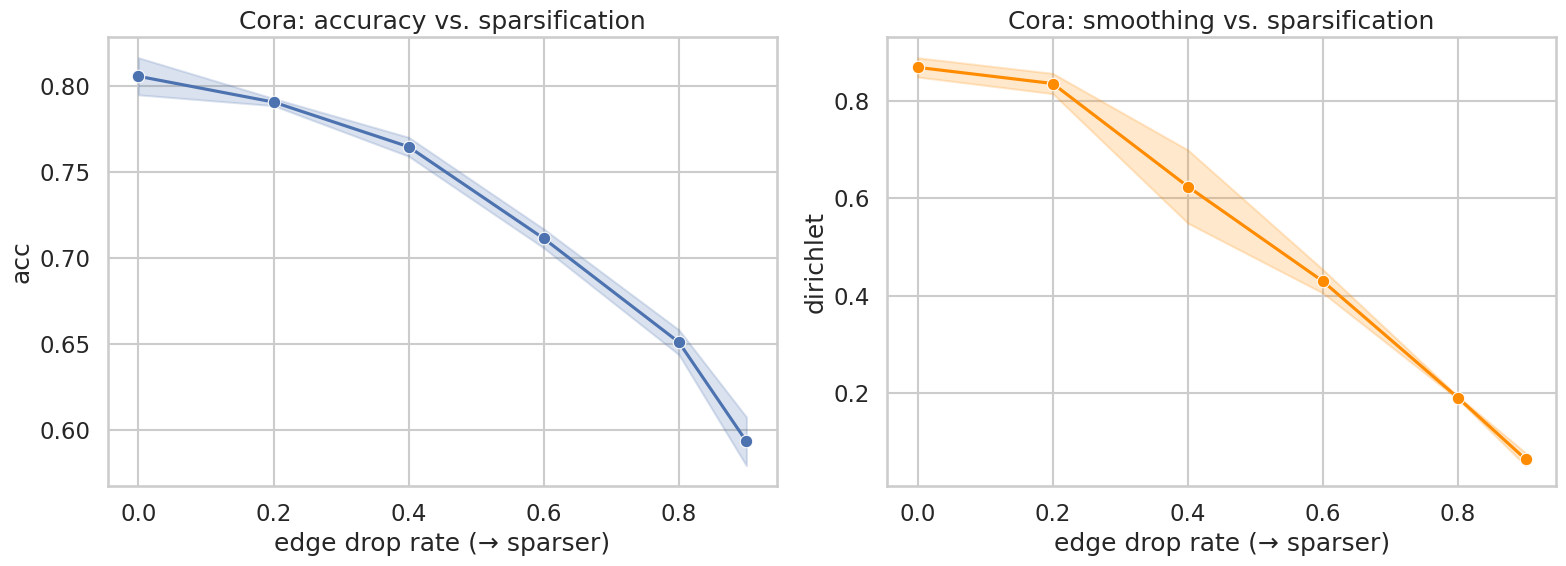

In [12]:
dataset = Planetoid(root="data/Cora", name="Cora"); base = dataset[0]
DROP_RATES=[0.0,0.2,0.4,0.6,0.8,0.9]; SEEDS5=[0,1,2]; rows=[]
for p in DROP_RATES:
    for s in SEEDS5:
        set_seed(s); data = base.clone()
        if p > 0:
            ei, _ = dropout_edge(data.edge_index, p=p, force_undirected=True); data.edge_index = ei
        data.num_classes = dataset.num_classes
        m = GNN(dataset.num_node_features, 64, dataset.num_classes, 2, "gcn")
        acc = train_node_classifier(data, m)
        with torch.no_grad():
            d = data.to(DEVICE); m = m.to(DEVICE).eval()
            _, emb = m(d.x, d.edge_index)
            de = dirichlet_energy(emb, d.edge_index, d.num_nodes)
        rows.append(dict(drop_rate=p, kept_edges=data.edge_index.size(1)//2, seed=s, acc=acc, dirichlet=de))
    print(f"drop {p} done")
df5 = pd.DataFrame(rows)
fig, ax = plt.subplots(1,2, figsize=(16,6))
sns.lineplot(data=df5, x="drop_rate", y="acc", marker="o", errorbar="sd", ax=ax[0])
ax[0].set_title("Cora: accuracy vs. sparsification"); ax[0].set_xlabel("edge drop rate (→ sparser)")
sns.lineplot(data=df5, x="drop_rate", y="dirichlet", marker="o", errorbar="sd", color="darkorange", ax=ax[1])
ax[1].set_title("Cora: smoothing vs. sparsification"); ax[1].set_xlabel("edge drop rate (→ sparser)")
plt.tight_layout(); plt.savefig(FIG_DIR/"06_cora_sparsification.png", dpi=150, bbox_inches="tight"); plt.show()
df5.to_csv(FIG_DIR/"exp5_cora.csv", index=False)

---
# Part III — Advanced extensions
Three additions move the study from *descriptive* to *explanatory*: a spectral mechanism, an analysis of which edges matter, and a heterophily robustness check.
    ## 9 · Spectral & rewiring utilities
Helpers for the advanced study: the normalized-Laplacian **spectral gap** $\lambda_2$ (governs information mixing), the propagation-operator **rate** $\mu$ (governs over-smoothing speed), and graph-reconstruction helpers used by the rewiring experiments.

In [13]:

import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import scipy.sparse.csgraph as csg

def to_scipy_adj(data):
    N = data.num_nodes; ei = data.edge_index.cpu().numpy()
    A = sp.coo_matrix((np.ones(ei.shape[1]), (ei[0], ei[1])), shape=(N, N))
    return ((A + A.T) > 0).astype(float).tocsr()

def giant_component_adj(A):
    nc, lab = csg.connected_components(A, directed=False)
    if nc == 1: return A
    keep = np.where(lab == np.bincount(lab).argmax())[0]
    return A[keep][:, keep]

def normalized_laplacian_gap(data):
    A = giant_component_adj(to_scipy_adj(data)); n = A.shape[0]
    if n < 4: return 0.0
    d = np.asarray(A.sum(1)).flatten(); di = 1/np.sqrt(np.maximum(d, 1e-12))
    L = sp.identity(n) - sp.diags(di) @ A @ sp.diags(di)
    vals = np.sort(eigsh(L, k=min(6, n-2), which='SA', return_eigenvectors=False))
    return float(vals[1])

def gcn_propagation_mu(data):
    A = to_scipy_adj(data); n = A.shape[0]
    A2 = A + sp.identity(n); d = np.asarray(A2.sum(1)).flatten(); di = 1/np.sqrt(d)
    P = sp.diags(di) @ A2 @ sp.diags(di)
    vals = np.sort(np.abs(eigsh(P, k=min(6, n-2), which='LM', return_eigenvectors=False)))[::-1]
    return float(vals[1])

def nx_to_data(G, ref):
    edges = np.array(G.edges()).T
    if edges.size == 0: edges = np.empty((2, 0), dtype=int)
    ei = torch.tensor(np.concatenate([edges, edges[::-1]], 1), dtype=torch.long)
    d = Data(x=ref.x.clone(), edge_index=ei, y=ref.y.clone()); d.num_classes = ref.num_classes
    for m in ['train_mask', 'val_mask', 'test_mask']:
        if hasattr(ref, m): setattr(d, m, getattr(ref, m).clone())
    return d
print("spectral + rewiring utilities ready")

spectral + rewiring utilities ready


## 10· The over-smoothing law
Establishes the *mechanism*: under repeated propagation, representations converge to the leading eigenvector of the propagation operator at the geometric rate $\mu$ (its second-largest $|\text{eigenvalue}|$). The measured residual slope should match $\log\mu$.

*Output:* `figures/07_oversmoothing_law.png`

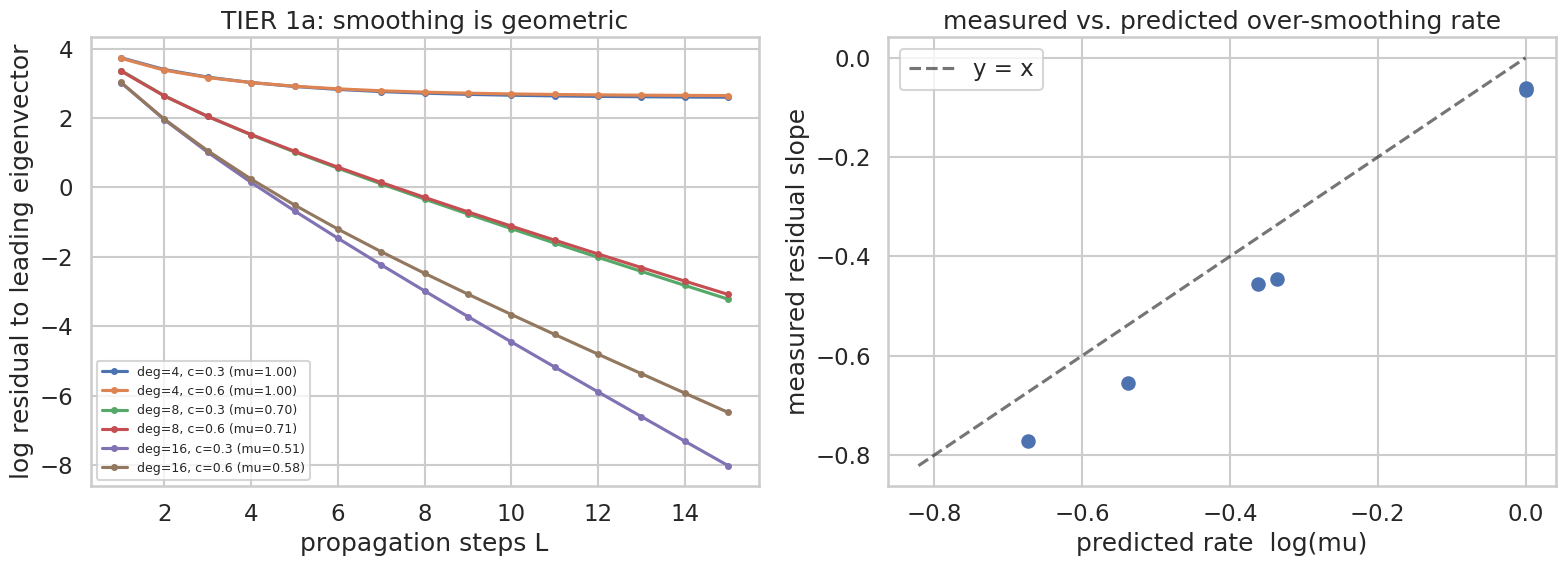

mean |measured - predicted| = 0.09


In [14]:

def oversmoothing_rate_check(data, depth=15, n_feat=16, seed=0):
    set_seed(seed)
    A = to_scipy_adj(data); n = A.shape[0]
    A2 = A + sp.identity(n); d = np.asarray(A2.sum(1)).flatten(); di = 1/np.sqrt(d)
    P = (sp.diags(di) @ A2 @ sp.diags(di)).toarray()
    w, V = np.linalg.eigh(P); order = np.argsort(np.abs(w))[::-1]; w, V = w[order], V[:, order]
    mu, v1 = abs(w[1]), V[:, 0:1]
    X = np.random.randn(n, n_feat); H = X.copy(); R = []
    for _ in range(depth):
        H = P @ H; R.append(np.linalg.norm(H - v1 @ (v1.T @ H)))
    R = np.array(R)
    slope = np.polyfit(np.arange(1, depth+1), np.log(R + 1e-30), 1)[0]
    return mu, slope, R

configs = [(d, c) for d in [4, 8, 16] for c in [0.3, 0.6]]
pred, meas = [], []
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for deg, c in configs:
    r = (1 - c) / (1 + c)
    data = make_sbm_data(avg_degree=deg, ratio=r, seed=0)
    mu, slope, R = oversmoothing_rate_check(data)
    pred.append(np.log(mu)); meas.append(slope)
    ax[0].plot(range(1, len(R)+1), np.log(R), marker='o', ms=4, label=f"deg={deg}, c={c} (mu={mu:.2f})")
ax[0].set_xlabel("propagation steps L"); ax[0].set_ylabel("log residual to leading eigenvector")
ax[0].set_title("TIER 1a: smoothing is geometric"); ax[0].legend(fontsize=9)
ax[1].scatter(pred, meas, s=80)
lim = [min(pred+meas)-0.05, 0]; ax[1].plot(lim, lim, 'k--', alpha=0.6, label="y = x")
ax[1].set_xlabel("predicted rate  log(mu)"); ax[1].set_ylabel("measured residual slope")
ax[1].set_title("measured vs. predicted over-smoothing rate"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"07_oversmoothing_law.png", dpi=150, bbox_inches="tight"); plt.show()
print("mean |measured - predicted| =", round(np.mean(np.abs(np.array(meas)-np.array(pred))), 3))

## 11. Spectral gap vs. edge count *(headline result)*
By varying **density** and community **contrast** in separate sweeps, we test whether node-classification accuracy is governed by the **spectral gap** $\lambda_2$ rather than by the raw edge count. If the two sweeps collapse onto one curve against $\lambda_2$ (high $R^2$) but not against degree, the spectral gap is the explanatory variable.

*Output:* `figures/08_disentangle_gap_vs_degree.png`, `figures/tier1_disentangle.csv`

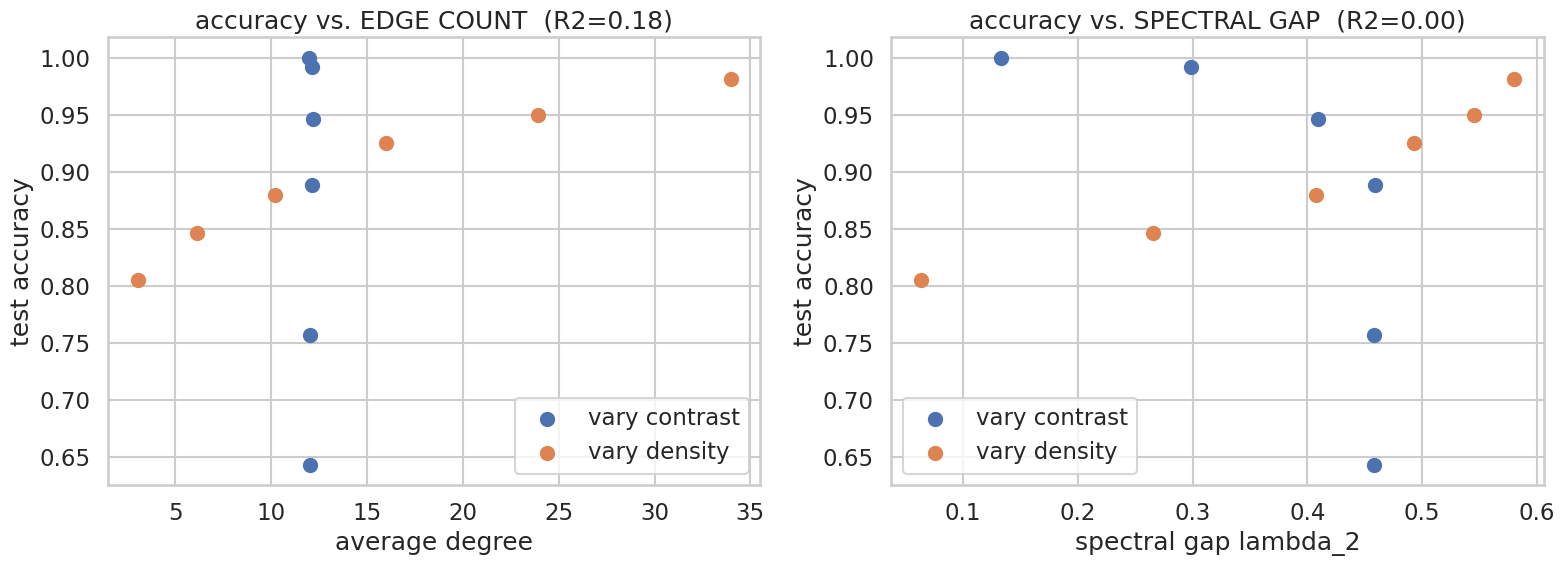

  acc   gap    mu  degree         sweep
0.805 0.063 1.000   3.029  vary density
0.847 0.265 0.862   6.101  vary density
0.880 0.408 0.635  10.175  vary density
0.925 0.493 0.537  16.008  vary density
0.950 0.545 0.477  23.894  vary density
0.982 0.580 0.437  33.981  vary density
0.643 0.458 0.580  12.028 vary contrast
0.757 0.458 0.580  12.017 vary contrast
0.888 0.459 0.579  12.142 vary contrast
0.947 0.409 0.623  12.186 vary contrast
0.992 0.299 0.724  12.133 vary contrast
1.000 0.133 0.878  11.968 vary contrast


In [15]:

def eval_config(avg_degree, contrast, seeds=(0,1,2)):
    r = (1 - contrast) / (1 + contrast)
    accs, gaps, mus, degs = [], [], [], []
    for s in seeds:
        data = add_random_splits(make_sbm_data(avg_degree=avg_degree, ratio=r, seed=s), seed=s)
        accs.append(train_node_classifier(data, GNN(data.num_node_features, 64, data.num_classes, 2, "gcn")))
        gaps.append(normalized_laplacian_gap(data)); mus.append(gcn_propagation_mu(data))
        degs.append(data.realized_avg_degree)
    return dict(acc=np.mean(accs), gap=np.mean(gaps), mu=np.mean(mus), degree=np.mean(degs))

rows = []
for deg in [3, 6, 10, 16, 24, 34]:
    rows.append({**eval_config(deg, contrast=0.5), "sweep": "vary density"})
for c in [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]:
    rows.append({**eval_config(12, contrast=c), "sweep": "vary contrast"})
dfT1 = pd.DataFrame(rows)

def r2(x, y):
    x, y = np.array(x), np.array(y)
    return 1 - np.sum((y - np.poly1d(np.polyfit(x, y, 1))(x))**2) / np.sum((y - y.mean())**2)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for sw, g in dfT1.groupby("sweep"):
    ax[0].scatter(g.degree, g.acc, s=90, label=sw)
    ax[1].scatter(g.gap, g.acc, s=90, label=sw)
ax[0].set_xlabel("average degree"); ax[0].set_ylabel("test accuracy")
ax[0].set_title(f"accuracy vs. EDGE COUNT  (R2={r2(dfT1.degree, dfT1.acc):.2f})"); ax[0].legend()
ax[1].set_xlabel("spectral gap lambda_2"); ax[1].set_ylabel("test accuracy")
ax[1].set_title(f"accuracy vs. SPECTRAL GAP  (R2={r2(dfT1.gap, dfT1.acc):.2f})"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"08_disentangle_gap_vs_degree.png", dpi=150, bbox_inches="tight"); plt.show()
dfT1.to_csv(FIG_DIR/"tier1_disentangle.csv", index=False)
print(dfT1.round(3).to_string(index=False))

## 12. Structure-aware rewiring
*Which* edges matter, not just how many. At a fixed edge budget we compare random additions against **curvature-guided (SDRF)**, **effective-resistance**, and **virtual-node** interventions (Lecture 8), measuring both accuracy and the spectral gap.

*Output:* `figures/09_rewiring_interventions.png`, `figures/tier2_rewiring.csv`

baseline (sparse) done
random +edges done
curvature (SDRF) done
eff. resistance done
virtual node done


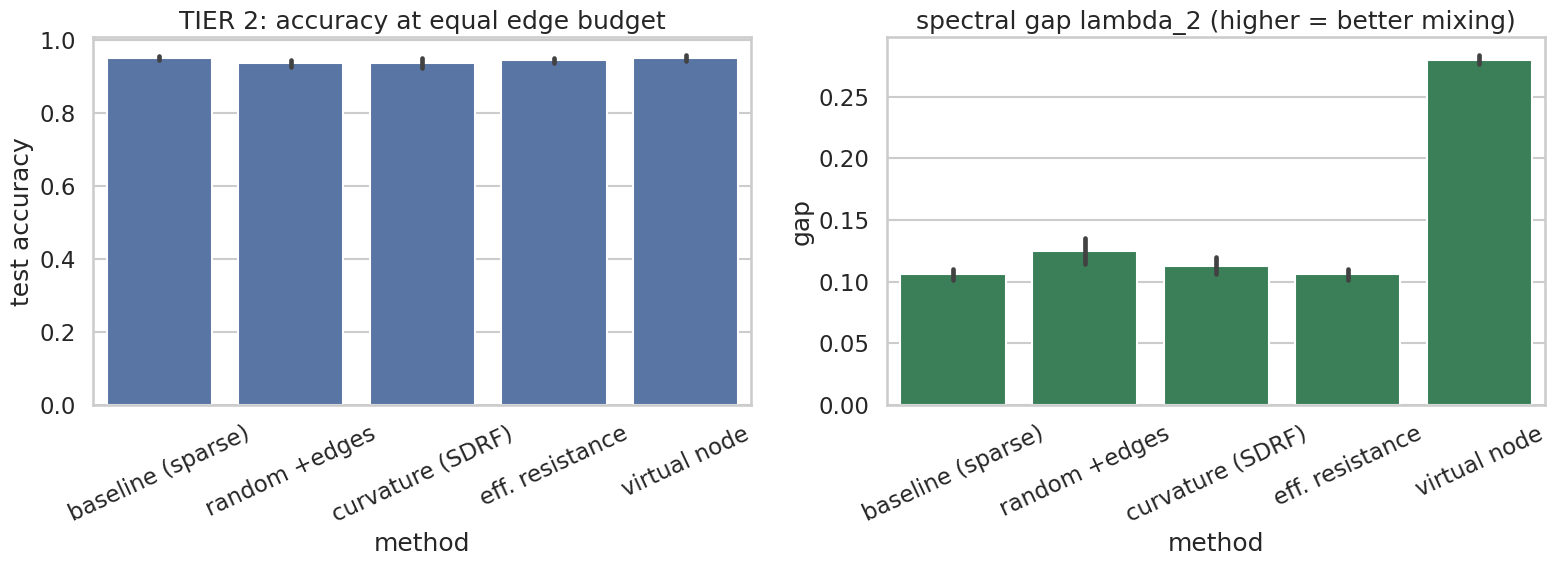

                     acc    gap
method                         
baseline (sparse)  0.950  0.106
curvature (SDRF)   0.937  0.113
eff. resistance    0.943  0.106
random +edges      0.935  0.125
virtual node       0.950  0.280


In [16]:

import random as _random

def forman_curvature(G, u, v):
    return 4 - G.degree(u) - G.degree(v) + 3*len(set(G.neighbors(u)) & set(G.neighbors(v)))

def sdrf_rewire(data, num_add=40, seed=0):
    set_seed(seed); G = to_networkx(data, to_undirected=True)
    for _ in range(num_add):
        edges = list(G.edges())
        u, v = edges[int(np.argmin([forman_curvature(G, a, b) for a, b in edges]))]
        nu, nv = list(G.neighbors(u)), list(G.neighbors(v))
        _random.shuffle(nu); _random.shuffle(nv); added = False
        for a in nu:
            for b in nv:
                if a != b and not G.has_edge(a, b):
                    G.add_edge(a, b); added = True; break
            if added: break
        if not added and not G.has_edge(u, v): G.add_edge(u, v)
    return nx_to_data(G, data)

def random_rewire(data, num_add=40, seed=0):
    set_seed(seed); G = to_networkx(data, to_undirected=True); N = data.num_nodes; k = 0
    while k < num_add:
        i, j = np.random.randint(0, N, 2)
        if i != j and not G.has_edge(i, j): G.add_edge(i, j); k += 1
    return nx_to_data(G, data)

def resistance_rewire(data, num_add=40, num_cand=600, seed=0):
    set_seed(seed); A = to_scipy_adj(data).toarray(); n = A.shape[0]
    Lp = np.linalg.pinv(np.diag(A.sum(1)) - A)
    cand = []
    while len(cand) < num_cand:
        i, j = np.random.randint(0, n, 2)
        if i != j and A[i, j] == 0: cand.append((i, j))
    res = sorted(((Lp[i, i] + Lp[j, j] - 2*Lp[i, j], i, j) for i, j in cand), reverse=True)
    G = to_networkx(data, to_undirected=True)
    for _, i, j in res[:num_add]: G.add_edge(int(i), int(j))
    return nx_to_data(G, data)

def add_virtual_node(data):
    N = data.num_nodes
    x = torch.cat([data.x, data.x.mean(0, keepdim=True)], 0)
    extra = torch.tensor([[N]*N + list(range(N)), list(range(N)) + [N]*N], dtype=torch.long)
    ei = torch.cat([data.edge_index, extra], 1)
    y = torch.cat([data.y, data.y.new_zeros(1)])
    d = Data(x=x, edge_index=ei, y=y); d.num_classes = data.num_classes
    for m in ['train_mask', 'val_mask', 'test_mask']:
        d.__setattr__(m, torch.cat([getattr(data, m), torch.zeros(1, dtype=torch.bool)]))
    return d

BUDGET, SEEDS2 = 40, [0, 1, 2]
interventions = {
    "baseline (sparse)": lambda d, s: d,
    "random +edges":     lambda d, s: random_rewire(d, BUDGET, s),
    "curvature (SDRF)":  lambda d, s: sdrf_rewire(d, BUDGET, s),
    "eff. resistance":   lambda d, s: resistance_rewire(d, BUDGET, s),
    "virtual node":      lambda d, s: add_virtual_node(d),
}
rows = []
for name, fn in interventions.items():
    for s in SEEDS2:
        base = add_random_splits(make_sbm_data(avg_degree=4, seed=s), seed=s)
        d = fn(base, s)
        acc = train_node_classifier(d, GNN(d.num_node_features, 64, d.num_classes, 3, "gcn"))
        gap = normalized_laplacian_gap(d)
        rows.append(dict(method=name, seed=s, acc=acc, gap=gap))
    print(name, "done")
dfT2 = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
order = list(interventions.keys())
sns.barplot(data=dfT2, x="method", y="acc", order=order, ax=ax[0], errorbar="sd")
ax[0].set_title("TIER 2: accuracy at equal edge budget"); ax[0].set_ylabel("test accuracy")
ax[0].tick_params(axis='x', rotation=25)
sns.barplot(data=dfT2, x="method", y="gap", order=order, ax=ax[1], errorbar="sd", color="seagreen")
ax[1].set_title("spectral gap lambda_2 (higher = better mixing)"); ax[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.savefig(FIG_DIR/"09_rewiring_interventions.png", dpi=150, bbox_inches="tight"); plt.show()
dfT2.to_csv(FIG_DIR/"tier2_rewiring.csv", index=False)
print(dfT2.groupby("method")[["acc", "gap"]].mean().round(3))

## 13. Heterophily robustness
Re-runs the core sparsity sweep on **disassortative** (heterophilous) SBM graphs, where mean-aggregation models such as GCN tend to fail and the sparsity/architecture ordering can flip. This is the project's built-in critical self-evaluation.

*Output:* `figures/10_heterophily.png`, `figures/tier3_heterophily.csv`

homophilous (p_in>>p_out) | degree 3 done
homophilous (p_in>>p_out) | degree 6 done
homophilous (p_in>>p_out) | degree 10 done
homophilous (p_in>>p_out) | degree 16 done
homophilous (p_in>>p_out) | degree 24 done
heterophilous (p_out>>p_in) | degree 3 done
heterophilous (p_out>>p_in) | degree 6 done
heterophilous (p_out>>p_in) | degree 10 done
heterophilous (p_out>>p_in) | degree 16 done
heterophilous (p_out>>p_in) | degree 24 done


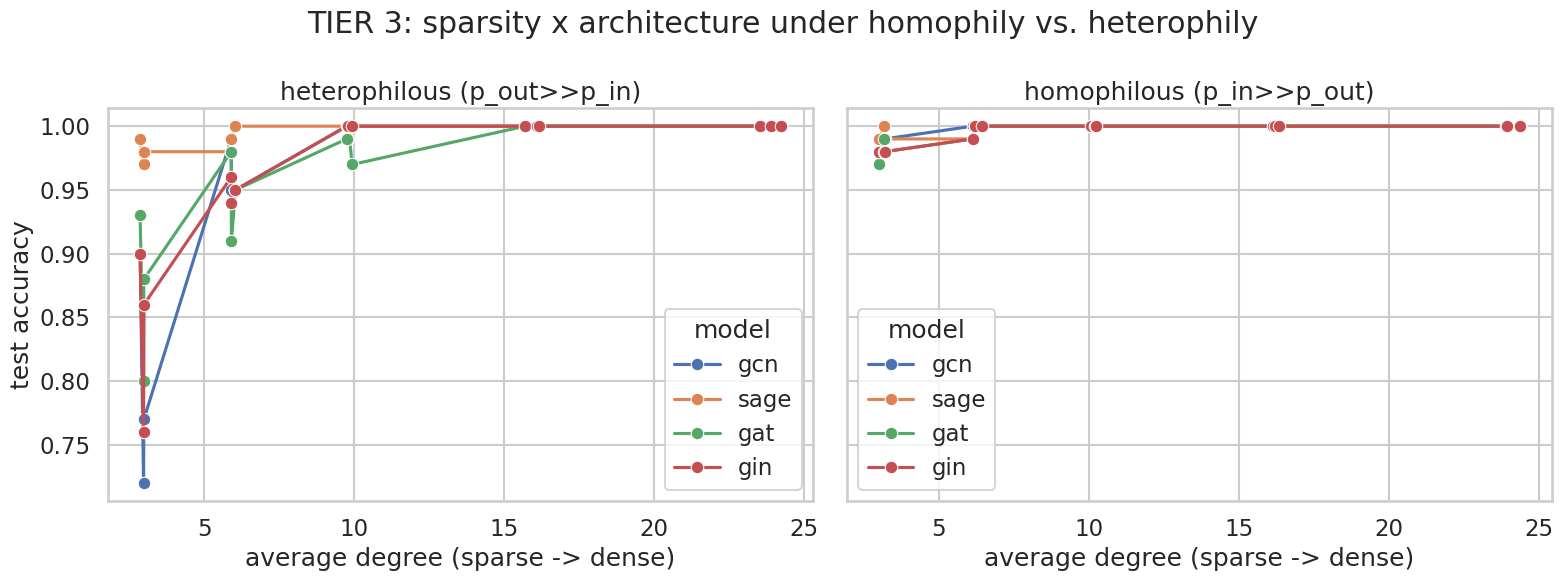

In [17]:

HET_DEGREES = [3, 6, 10, 16, 24]
HET_ARCHS = ["gcn", "sage", "gat", "gin"]
HET_SEEDS = [0, 1, 2]
REGIMES = {"homophilous (p_in>>p_out)": 0.1, "heterophilous (p_out>>p_in)": 8.0}

rows = []
for reg, ratio in REGIMES.items():
    for deg in HET_DEGREES:
        for s in HET_SEEDS:
            data = add_random_splits(
                make_sbm_data(avg_degree=deg, n_blocks=2, ratio=ratio, seed=s), seed=s)
            in_dim, out_dim = data.num_node_features, data.num_classes
            for arch in HET_ARCHS:
                acc = train_node_classifier(data, GNN(in_dim, 64, out_dim, 2, arch))
                rows.append(dict(regime=reg, degree=data.realized_avg_degree,
                                 model=arch, seed=s, acc=acc))
        print(f"{reg} | degree {deg} done")
dfT3 = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for a, (reg, g) in zip(ax, dfT3.groupby("regime")):
    sns.lineplot(data=g, x="degree", y="acc", hue="model", marker="o", errorbar="sd", ax=a)
    a.set_title(reg); a.set_xlabel("average degree (sparse -> dense)"); a.set_ylabel("test accuracy")
fig.suptitle("TIER 3: sparsity x architecture under homophily vs. heterophily")
plt.tight_layout(); plt.savefig(FIG_DIR/"10_heterophily.png", dpi=150, bbox_inches="tight"); plt.show()
dfT3.to_csv(FIG_DIR/"tier3_heterophily.csv", index=False)